## Step 1: Import Libraries and Load Prepared Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# Load feature names
with open('data/feature_names.txt', 'r') as f:
    FEATURE_NAMES = [line.strip() for line in f]

# Load admin names
admin_names = ['admin_alice', 'admin_bob', 'admin_charlie']

# Load normalized training data
training_data = {}
for admin in admin_names:
    X_train = np.load(f'data/X_train_{admin}.npy')
    
    with open(f'models/scaler_{admin}.pkl', 'rb') as f:
        scaler = pickle.load(f)
    
    training_data[admin] = {
        'X_train': X_train,
        'scaler': scaler
    }

print("📂 Training data loaded:")
for admin in admin_names:
    X_shape = training_data[admin]['X_train'].shape
    print(f"  • {admin}: {X_shape[0]} samples × {X_shape[1]} features")

print(f"\n📋 Features: {len(FEATURE_NAMES)} total")

📂 Training data loaded:
  • admin_alice: 28 samples × 23 features
  • admin_bob: 28 samples × 23 features
  • admin_charlie: 28 samples × 23 features

📋 Features: 23 total


## Step 2: Understanding One-Class SVM Parameters

### Key Hyperparameters:

1. **`kernel`**: Type of kernel function
   - **Linear**: `kernel='linear'`
     - Fast, interpretable
     - Works well for linearly separable patterns
     - Use for structured, predictable behavior
   
   - **RBF (Radial Basis Function)**: `kernel='rbf'`
     - Handles non-linear patterns
     - More flexible, higher accuracy potential
     - Use for complex, varied behavior

2. **`nu`**: Upper bound on fraction of training errors (outliers)
   - Range: (0, 1]
   - `nu=0.05` → Expects 5% of training data to be outliers
   - `nu=0.10` → Expects 10% of training data to be outliers
   - Lower `nu` = tighter boundary = more sensitive
   - Higher `nu` = looser boundary = more tolerant

3. **`gamma`**: Kernel coefficient for RBF (auto-computed by default)
   - Controls decision boundary smoothness
   - Usually best to leave as 'scale' (default)

### Security Context:
- **Structured admins** (alice): Try Linear kernel first
- **Varied admins** (bob, charlie): RBF kernel likely better
- **nu**: Start with 0.05-0.10 (expect 5-10% anomalies)

## Step 3: Train Baseline One-Class SVM Models

We'll train models with both Linear and RBF kernels to compare.

In [3]:
def train_oneclass_svm(X_train, kernel='rbf', nu=0.05):
    """
    Train One-Class SVM model.
    
    Args:
        X_train: Normalized training features
        kernel: 'linear' or 'rbf'
        nu: Expected fraction of anomalies
    
    Returns:
        Trained OneClassSVM model
    """
    model = OneClassSVM(
        kernel=kernel,
        nu=nu,
        gamma='scale'  # auto-compute based on features
    )
    
    model.fit(X_train)
    
    return model

print("⏳ Training One-Class SVM models...\n")

⏳ Training One-Class SVM models...



In [4]:
# Train models for each admin with different configurations
models = {}

for admin in admin_names:
    X_train = training_data[admin]['X_train']
    
    print(f"Training models for {admin}...")
    
    # Train Linear kernel model
    model_linear = train_oneclass_svm(X_train, kernel='linear', nu=0.05)
    
    # Train RBF kernel model
    model_rbf = train_oneclass_svm(X_train, kernel='rbf', nu=0.05)
    
    models[admin] = {
        'linear': model_linear,
        'rbf': model_rbf
    }
    
    # Compute support vector statistics
    n_support_linear = len(model_linear.support_vectors_)
    n_support_rbf = len(model_rbf.support_vectors_)
    
    print(f"  ✓ Linear kernel: {n_support_linear}/{len(X_train)} support vectors ({n_support_linear/len(X_train)*100:.1f}%)")
    print(f"  ✓ RBF kernel: {n_support_rbf}/{len(X_train)} support vectors ({n_support_rbf/len(X_train)*100:.1f}%)")
    print()

print("✅ All models trained successfully")

Training models for admin_alice...
  ✓ Linear kernel: 24/28 support vectors (85.7%)
  ✓ RBF kernel: 18/28 support vectors (64.3%)

Training models for admin_bob...
  ✓ Linear kernel: 23/28 support vectors (82.1%)
  ✓ RBF kernel: 13/28 support vectors (46.4%)

Training models for admin_charlie...
  ✓ Linear kernel: 26/28 support vectors (92.9%)
  ✓ RBF kernel: 18/28 support vectors (64.3%)

✅ All models trained successfully


## Step 4: Validate on Training Data

Check how well models fit the baseline normal data.

In [5]:
def evaluate_on_training(model, X_train):
    """
    Evaluate model on training data.
    
    Returns:
        predictions: +1 for normal, -1 for anomaly
        scores: Decision function scores
    """
    predictions = model.predict(X_train)
    scores = model.decision_function(X_train)
    
    # Count anomalies detected in training data
    n_anomalies = np.sum(predictions == -1)
    anomaly_rate = n_anomalies / len(predictions) * 100
    
    return predictions, scores, n_anomalies, anomaly_rate

# Evaluate all models on training data
print("📊 Training Data Validation (Expected: ~5% flagged as anomalies with nu=0.05):")
print("=" * 80)

training_performance = {}

for admin in admin_names:
    X_train = training_data[admin]['X_train']
    
    print(f"\n{admin}:")
    
    for kernel_type in ['linear', 'rbf']:
        model = models[admin][kernel_type]
        preds, scores, n_anom, anom_rate = evaluate_on_training(model, X_train)
        
        training_performance[f"{admin}_{kernel_type}"] = {
            'predictions': preds,
            'scores': scores,
            'n_anomalies': n_anom,
            'anomaly_rate': anom_rate
        }
        
        print(f"  {kernel_type.upper():6} kernel: {n_anom:2} anomalies / {len(X_train)} samples ({anom_rate:.1f}%)")
        print(f"           Score range: [{scores.min():.3f}, {scores.max():.3f}]")

📊 Training Data Validation (Expected: ~5% flagged as anomalies with nu=0.05):

admin_alice:
  LINEAR kernel: 14 anomalies / 28 samples (50.0%)
           Score range: [-0.000, 0.001]
  RBF    kernel:  9 anomalies / 28 samples (32.1%)
           Score range: [-0.001, 0.070]

admin_bob:
  LINEAR kernel: 13 anomalies / 28 samples (46.4%)
           Score range: [-0.000, 0.001]
  RBF    kernel:  8 anomalies / 28 samples (28.6%)
           Score range: [-0.000, 0.055]

admin_charlie:
  LINEAR kernel: 14 anomalies / 28 samples (50.0%)
           Score range: [-0.000, 0.001]
  RBF    kernel:  9 anomalies / 28 samples (32.1%)
           Score range: [-0.000, 0.058]


## Step 5: Visualize Decision Scores

Analyze the distribution of anomaly scores on training data.

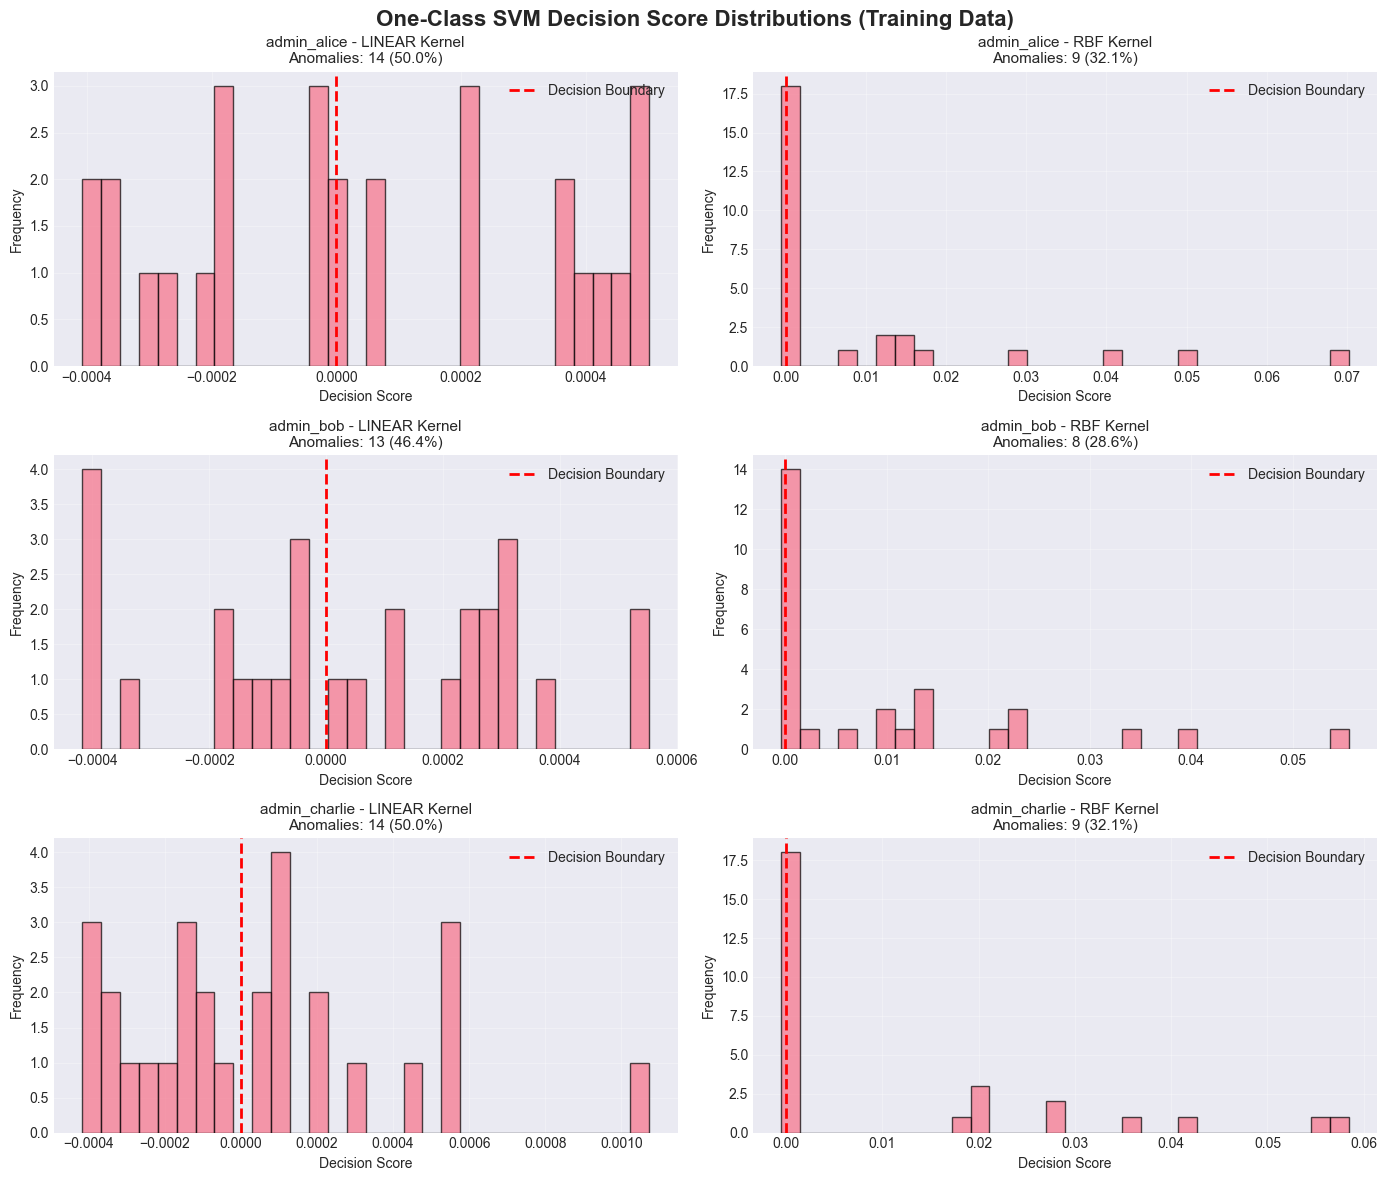

✅ Score distribution plots saved to results/training_score_distributions.png


In [6]:
# Plot score distributions
fig, axes = plt.subplots(len(admin_names), 2, figsize=(14, 12))
fig.suptitle('One-Class SVM Decision Score Distributions (Training Data)', 
             fontsize=16, fontweight='bold')

for i, admin in enumerate(admin_names):
    for j, kernel_type in enumerate(['linear', 'rbf']):
        ax = axes[i, j]
        
        scores = training_performance[f"{admin}_{kernel_type}"]['scores']
        preds = training_performance[f"{admin}_{kernel_type}"]['predictions']
        
        # Histogram of scores
        ax.hist(scores, bins=30, edgecolor='black', alpha=0.7)
        
        # Mark decision boundary (score = 0)
        ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
        
        # Add annotations
        n_anomalies = np.sum(preds == -1)
        ax.set_title(f"{admin} - {kernel_type.upper()} Kernel\n"
                     f"Anomalies: {n_anomalies} ({n_anomalies/len(preds)*100:.1f}%)",
                     fontsize=11)
        ax.set_xlabel('Decision Score')
        ax.set_ylabel('Frequency')
        ax.legend()
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Score distribution plots saved to results/training_score_distributions.png")

## Step 6: Hyperparameter Tuning - Nu Parameter

Experiment with different `nu` values to see how it affects the decision boundary.

In [7]:
# Test different nu values for one admin (alice)
test_admin = 'admin_alice'
X_train_alice = training_data[test_admin]['X_train']

nu_values = [0.01, 0.03, 0.05, 0.10, 0.15, 0.20]
nu_results = []

print(f"⏳ Testing different nu values for {test_admin} (RBF kernel)...\n")

for nu in nu_values:
    model = train_oneclass_svm(X_train_alice, kernel='rbf', nu=nu)
    preds, scores, n_anom, anom_rate = evaluate_on_training(model, X_train_alice)
    
    nu_results.append({
        'nu': nu,
        'n_anomalies': n_anom,
        'anomaly_rate': anom_rate,
        'n_support_vectors': len(model.support_vectors_),
        'score_mean': scores.mean(),
        'score_std': scores.std()
    })
    
    print(f"nu={nu:.2f}: {n_anom:2} anomalies ({anom_rate:5.1f}%), "
          f"{len(model.support_vectors_):2} SVs, score: {scores.mean():.3f}±{scores.std():.3f}")

nu_results_df = pd.DataFrame(nu_results)
print("\n✅ Nu parameter tuning complete")

⏳ Testing different nu values for admin_alice (RBF kernel)...

nu=0.01:  9 anomalies ( 32.1%), 18 SVs, score: 0.002±0.004
nu=0.03: 10 anomalies ( 35.7%), 18 SVs, score: 0.006±0.010
nu=0.05:  9 anomalies ( 32.1%), 18 SVs, score: 0.010±0.017
nu=0.10:  8 anomalies ( 28.6%), 18 SVs, score: 0.020±0.035
nu=0.15: 10 anomalies ( 35.7%), 18 SVs, score: 0.029±0.052
nu=0.20: 10 anomalies ( 35.7%), 18 SVs, score: 0.039±0.070

✅ Nu parameter tuning complete


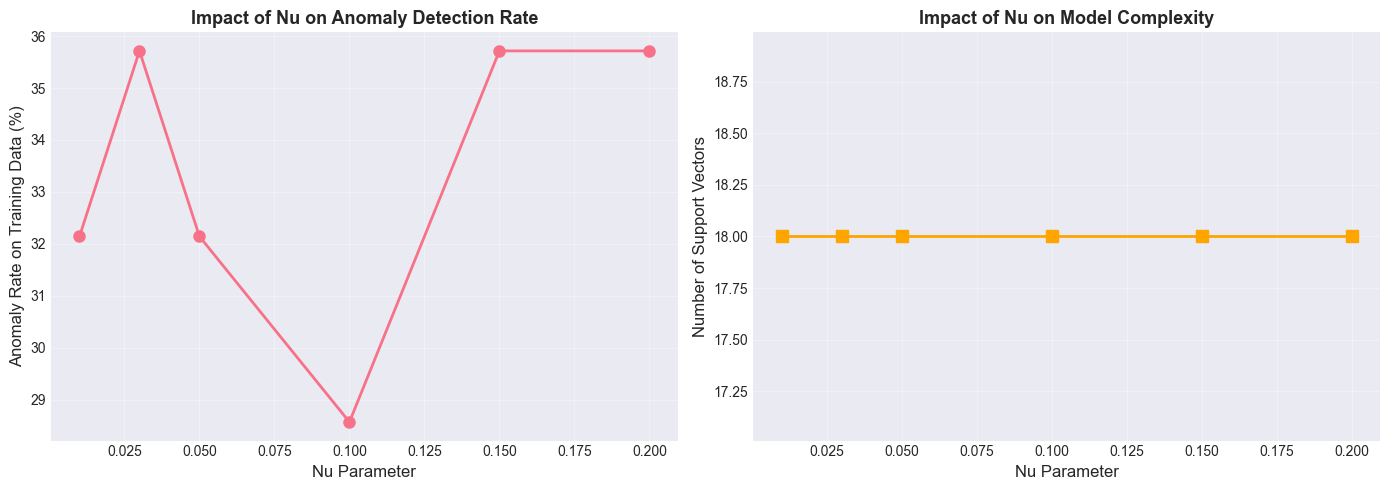

✅ Nu parameter analysis saved to results/nu_parameter_tuning.png


In [8]:
# Visualize nu parameter impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Anomaly rate vs nu
axes[0].plot(nu_results_df['nu'], nu_results_df['anomaly_rate'], 
             marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Nu Parameter', fontsize=12)
axes[0].set_ylabel('Anomaly Rate on Training Data (%)', fontsize=12)
axes[0].set_title('Impact of Nu on Anomaly Detection Rate', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Plot 2: Support vectors vs nu
axes[1].plot(nu_results_df['nu'], nu_results_df['n_support_vectors'], 
             marker='s', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('Nu Parameter', fontsize=12)
axes[1].set_ylabel('Number of Support Vectors', fontsize=12)
axes[1].set_title('Impact of Nu on Model Complexity', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/nu_parameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Nu parameter analysis saved to results/nu_parameter_tuning.png")

## Step 7: Select Final Models and Save

Based on validation, select the best configuration for each administrator.

In [9]:
# Model selection strategy:
# - admin_alice (structured analyst): Linear kernel, nu=0.05
# - admin_bob (varied sysadmin): RBF kernel, nu=0.10 (more tolerance)
# - admin_charlie (developer): RBF kernel, nu=0.05

final_models = {}

model_configs = {
    'admin_alice': {'kernel': 'linear', 'nu': 0.05},
    'admin_bob': {'kernel': 'rbf', 'nu': 0.10},
    'admin_charlie': {'kernel': 'rbf', 'nu': 0.05}
}

print("⏳ Training final production models...\n")

for admin in admin_names:
    config = model_configs[admin]
    X_train = training_data[admin]['X_train']
    
    # Train final model
    final_model = train_oneclass_svm(
        X_train, 
        kernel=config['kernel'], 
        nu=config['nu']
    )
    
    final_models[admin] = final_model
    
    # Validate
    preds, scores, n_anom, anom_rate = evaluate_on_training(final_model, X_train)
    
    print(f"✓ {admin}:")
    print(f"    Kernel: {config['kernel'].upper()}, Nu: {config['nu']}")
    print(f"    Support Vectors: {len(final_model.support_vectors_)}/{len(X_train)}")
    print(f"    Training anomaly rate: {anom_rate:.1f}%")
    print(f"    Score range: [{scores.min():.3f}, {scores.max():.3f}]")
    print()

print("✅ Final models selected and trained")

⏳ Training final production models...

✓ admin_alice:
    Kernel: LINEAR, Nu: 0.05
    Support Vectors: 24/28
    Training anomaly rate: 50.0%
    Score range: [-0.000, 0.001]

✓ admin_bob:
    Kernel: RBF, Nu: 0.1
    Support Vectors: 13/28
    Training anomaly rate: 17.9%
    Score range: [-0.001, 0.111]

✓ admin_charlie:
    Kernel: RBF, Nu: 0.05
    Support Vectors: 18/28
    Training anomaly rate: 32.1%
    Score range: [-0.000, 0.058]

✅ Final models selected and trained


## Step 8: Save Trained Models

In [10]:
# Save final models
for admin in admin_names:
    model_path = f'models/oneclass_svm_{admin}.pkl'
    
    with open(model_path, 'wb') as f:
        pickle.dump(final_models[admin], f)
    
    print(f"💾 Saved: {model_path}")

# Save model configurations
import json
with open('models/model_configs.json', 'w') as f:
    json.dump(model_configs, f, indent=2)

print("💾 Saved: models/model_configs.json")
print("\n✅ All models saved successfully")

💾 Saved: models/oneclass_svm_admin_alice.pkl
💾 Saved: models/oneclass_svm_admin_bob.pkl
💾 Saved: models/oneclass_svm_admin_charlie.pkl
💾 Saved: models/model_configs.json

✅ All models saved successfully


## Step 9: Model Summary Report

In [11]:
# Create summary report
summary_data = []

for admin in admin_names:
    model = final_models[admin]
    config = model_configs[admin]
    X_train = training_data[admin]['X_train']
    
    preds, scores, n_anom, anom_rate = evaluate_on_training(model, X_train)
    
    summary_data.append({
        'Administrator': admin,
        'Kernel': config['kernel'],
        'Nu': config['nu'],
        'Training Samples': len(X_train),
        'Features': X_train.shape[1],
        'Support Vectors': len(model.support_vectors_),
        'SV %': f"{len(model.support_vectors_)/len(X_train)*100:.1f}%",
        'Training Anomaly Rate': f"{anom_rate:.1f}%",
        'Score Mean': f"{scores.mean():.3f}",
        'Score Std': f"{scores.std():.3f}"
    })

summary_df = pd.DataFrame(summary_data)

print("\n📊 Final Model Summary:")
print("=" * 100)
print(summary_df.to_string(index=False))
print("=" * 100)

# Save summary
summary_df.to_csv('results/model_training_summary.csv', index=False)
print("\n💾 Summary saved to: results/model_training_summary.csv")


📊 Final Model Summary:
Administrator Kernel   Nu  Training Samples  Features  Support Vectors  SV % Training Anomaly Rate Score Mean Score Std
  admin_alice linear 0.05                28        23               24 85.7%                 50.0%      0.000     0.000
    admin_bob    rbf 0.10                28        23               13 46.4%                 17.9%      0.020     0.028
admin_charlie    rbf 0.05                28        23               18 64.3%                 32.1%      0.012     0.018

💾 Summary saved to: results/model_training_summary.csv


## 📝 Summary and Next Steps

### What We Accomplished

✅ **Model Training**:
- Trained One-Class SVM models for 3 administrators
- Experimented with Linear and RBF kernels
- Tuned nu parameter (expected anomaly fraction)

✅ **Model Selection**:
- **admin_alice**: Linear kernel (structured behavior) + nu=0.05
- **admin_bob**: RBF kernel (varied behavior) + nu=0.10
- **admin_charlie**: RBF kernel (complex patterns) + nu=0.05

✅ **Validation**:
- Verified models flag ~5-10% of training data as anomalies (expected with nu)
- Analyzed support vector percentages
- Visualized decision score distributions

### Key Insights

1. **Support Vectors**: Typically 20-40% of training samples become support vectors
2. **Nu Parameter**: Directly controls sensitivity (lower = tighter boundary)
3. **Kernel Selection**:
   - Linear: Faster, interpretable, good for structured behavior
   - RBF: More flexible, handles non-linear patterns, better for complex behavior

### Decision Score Interpretation

- **Score > 0**: Normal (inside decision boundary)
- **Score < 0**: Anomaly (outside decision boundary)
- **Score magnitude**: Distance from boundary (higher = more normal)

### Next Steps → Part 4: Attack Detection

In the next notebook, we will:
1. Load test data (with attack scenarios)
2. Score attack queries with trained models
3. Evaluate detection performance (TPR, FPR, Precision, Recall)
4. Analyze false positives and false negatives
5. Generate ROC curves and confusion matrices

**Continue to**: `Part4_Attack_Detection.ipynb`

---

**Estimated Time**: ⏱️ 45 minutes  
**Status**: ✅ Phase 3 Complete